In [ ]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import du processeur de production spécialisé
from tools.OI_class_OP import OI_DataProcessor

# Configuration de l'affichage pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

In [2]:
# Cellule 2 : Définition des métadonnées de tags API
tags = [
    {'tag':'NOP_ESTERS', 'nom':'value_nop','info':"Nombres des opérations",'agg':'FIRST' },
]

In [3]:
# Cellule 4 : Initialisation du processeur de production spécialisé
processor = OI_DataProcessor(
    url_base = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    start = '2016-01-01',
    end = '2026-12-31',
    tags_selected = tags,
    tags_other = [],
    interval = 'PT01M',
    verbose = False,
    agg = 'FIRST'
)

In [4]:
# Cellule 5 : Téléchargement et calcul automatique des bilans par produit
processor.merge()

# Visualisation des premières lignes calculées
processor.data.describe()

,value_nop
count,5.509057e+06
mean,8.719467e+02
std,5.887431e+02
min,0.000000e+00
25%,3.390000e+02
50%,7.980000e+02
75%,1.346000e+03
max,2.272000e+03


In [5]:
# debut = '01-01-2020 02:00:00'
# fin = '07-03-2026 02:00:00'
# NOP = processor.data.loc[[fin],['value_nop']].values[0] - processor.data.loc[[debut],['value_nop']].values[0]
# print('Value NOP   : ', NOP, NOP * 2.71)
# processor.data[debut:fin]

In [6]:
def extract_operations(df, value_col="value_nop"):
    # Nettoyage
    df = df.copy()
    df = df.dropna(subset=[value_col])
    df = df[df[value_col] >= 0]
    df[value_col] = df[value_col].round().astype("int64")

    # Ordre chronologique
    df = df.sort_index()

    # Détection des changements
    df["operation_id"] = (df[value_col] != df[value_col].shift()).cumsum()

    # Résumé de chaque opération
    operations = (
        df.groupby("operation_id")
          .agg(
              value=(value_col, "first"),
              start=("operation_id", lambda x: x.index[0]),
              end=("operation_id", lambda x: x.index[-1]),
              n_samples=(value_col, "size")
          )
    )

    # Durée
    operations["duration"] = operations["end"] - operations["start"]

    return operations.reset_index(drop=True)

In [7]:
def extract_operations_(df, value_col="value_nop"):
    """
    Extrait les opérations successives d'une série temporelle.

    Parameters
    ----------
    df : DataFrame
        Index = DatetimeIndex
        value_col = numéro d'opération

    Returns
    -------
    operations : DataFrame
        operation_id
        value
        start
        end
        duration
        duration_min
        n_samples
    """

    # ------------------------------------------------------------------
    # Nettoyage
    # ------------------------------------------------------------------
    df = df.copy()

    df = df.dropna(subset=[value_col])
    df = df[df[value_col] >= 0]

    df[value_col] = (
        df[value_col]
        .round()
        .astype("int64")
    )

    df = df.sort_index()

    # ------------------------------------------------------------------
    # Détection des changements d'opération
    # ------------------------------------------------------------------
    change = df[value_col].ne(df[value_col].shift())

    starts = df.loc[change, [value_col]].copy()
    starts.rename(columns={value_col: "value"}, inplace=True)

    starts["start"] = starts.index

    # ------------------------------------------------------------------
    # Fin = début de la prochaine opération
    # ------------------------------------------------------------------
    starts["end"] = starts["start"].shift(-1)

    # dernière opération
    starts.iloc[-1, starts.columns.get_loc("end")] = df.index[-1]

    # ------------------------------------------------------------------
    # Durée
    # ------------------------------------------------------------------
    starts["duration"] = starts["end"] - starts["start"]

    starts["duration_min"] = (
        starts["duration"]
        .dt.total_seconds()
        / 60
    )

    # ------------------------------------------------------------------
    # Nombre d'échantillons
    # ------------------------------------------------------------------
    starts["n_samples"] = (
        df.groupby(change.cumsum())
        .size()
        .to_numpy()
    )

    starts["operation_id"] = range(len(starts))

    return (
        starts[
            [
                "operation_id",
                "value",
                "start",
                "end",
                "duration",
                "duration_min",
                "n_samples",
            ]
        ]
        .reset_index(drop=True)
    )

In [8]:
def extract_operations_DIT(df: pd.DataFrame,
                       value_col: str = "value_nop") -> pd.DataFrame:
    """
    Extrait les opérations d'une série temporelle.

    Paramètres
    ----------
    df : DataFrame
        Index = DatetimeIndex
        Colonne = value_col

    Retour
    ------
    DataFrame contenant :
        operation_id
        value
        start
        end
        duration
        duration_min
        n_samples
    """

    # ------------------------------------------------------------------
    # 1. Nettoyage
    # ------------------------------------------------------------------
    df = df.copy()

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Le DataFrame doit être indexé par un DatetimeIndex.")

    df = df.sort_index()

    df = df.dropna(subset=[value_col])
    df = df[df[value_col] >= 0]

    df[value_col] = (
        df[value_col]
        .round()
        .astype("int64")
    )

    # ------------------------------------------------------------------
    # 2. Détection des changements d'opération
    # ------------------------------------------------------------------
    change = df[value_col].ne(df[value_col].shift())

    operations = df.loc[change, [value_col]].copy()

    operations.rename(columns={value_col: "value"}, inplace=True)

    operations["start"] = operations.index

    operations.reset_index(drop=True, inplace=True)

    operations["operation_id"] = operations.index

    # ------------------------------------------------------------------
    # 3. Fin = début de l'opération suivante
    # ------------------------------------------------------------------
    operations["end"] = operations["start"].shift(-1)

    # Dernière opération
    operations.loc[
        operations.index[-1],
        "end"
    ] = df.index[-1]

    # ------------------------------------------------------------------
    # 4. Durée
    # ------------------------------------------------------------------
    operations["duration"] = (
        operations["end"] - operations["start"]
    )

    operations["duration_min"] = (
        operations["duration"]
        .dt.total_seconds() / 60
    )

    # ------------------------------------------------------------------
    # 5. Nombre d'échantillons
    # ------------------------------------------------------------------
    operations["n_samples"] = (
        df.groupby(change.cumsum())
          .size()
          .to_numpy()
    )

    return operations[
        [
            "operation_id",
            "value",
            "start",
            "end",
            "duration",
            "duration_min",
            "n_samples"
        ]
    ]

In [9]:
ops = extract_operations_(processor.data)

mask_max = ops["duration"] <= pd.Timedelta(hours=24)
mask_min = ops["duration"] >= pd.Timedelta(hours=4)

print(f"Opérations conservées MAX: {mask_max.sum():,}")
print(f"Opérations supprimées MAX: {(~mask_max).sum():,}")
print(f"Opérations conservées MIN: {mask_min.sum():,}")
print(f"Opérations supprimées MIN: {(~mask_min).sum():,}")

ops = ops[mask_max].copy()
ops = ops[mask_min].copy()
ops.describe()

Opérations conservées MAX: 9,261
Opérations supprimées MAX: 180
Opérations conservées MIN: 9,318
Opérations supprimées MIN: 123


/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_38868/3284484351.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ops = ops[mask_min].copy()


,operation_id,value,duration,duration_min,n_samples
count,9138.000000,9138.000000,9138,9138.000000,9138.000000
mean,4718.266470,922.660976,0 days 07:52:18.903479973,472.315058,470.964106
std,2726.304283,568.893222,0 days 02:38:49.510815522,158.825180,158.316063
min,1.000000,1.000000,0 days 04:00:00,240.000000,147.000000
25%,2363.250000,459.250000,0 days 06:27:00,387.000000,387.000000
50%,4713.500000,847.500000,0 days 07:02:00,422.000000,421.000000
75%,7076.750000,1376.000000,0 days 08:18:00,498.000000,497.000000
max,9440.000000,2272.000000,0 days 23:59:00,1439.000000,1439.000000


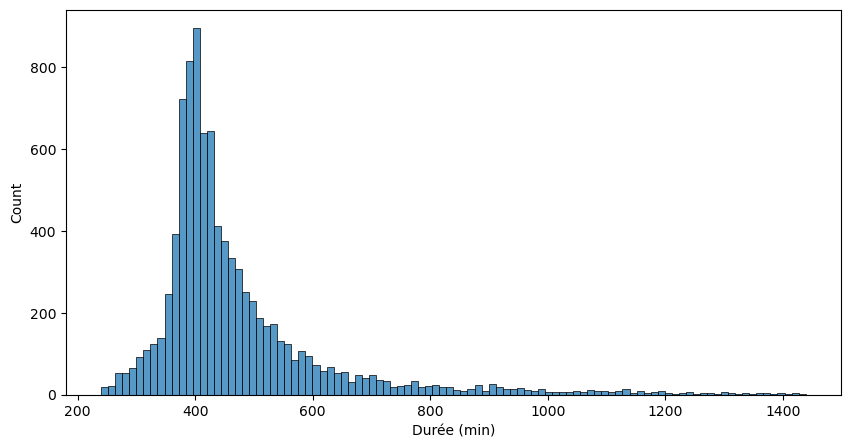

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(ops["duration_min"], bins=100)
plt.xlabel("Durée (min)")
plt.show()

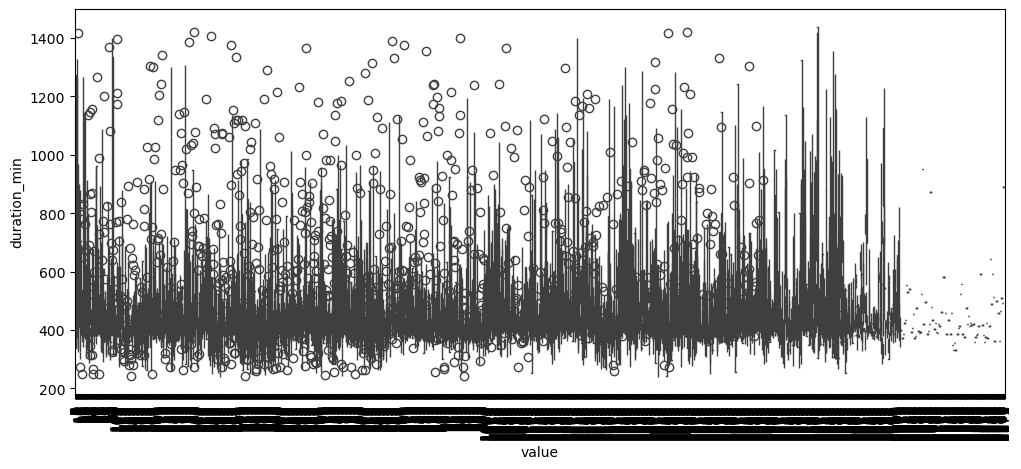

In [11]:
plt.figure(figsize=(12,5))
sns.boxplot(data=ops, x="value", y="duration_min")
plt.xticks(rotation=90)
plt.show()

In [12]:
def best_sequences_ops(ops, window_sizes=(9, 15, 25)):
    
    ops = ops.sort_values("start").reset_index(drop=True)

    durations = ops["duration_min"].values
    values = ops["value"].values

    results = {}

    for w in window_sizes:
        if len(durations) < w:
            continue

        rolling_sum = np.convolve(durations, np.ones(w), mode="valid")
        best_idx = np.argmin(rolling_sum)

        results[w] = {
            "start_idx": best_idx,
            "end_idx": best_idx + w,
            "values": values[best_idx:best_idx + w],
            "start_time": ops.loc[best_idx, "start"],
            "end_time": ops.loc[best_idx + w - 1, "end"],
            "total_duration": rolling_sum[best_idx],
            "mean_duration": rolling_sum[best_idx] / w
        }

    return results

In [13]:
results = best_sequences_ops(ops, window_sizes=(9, 15, 25))

for w, r in results.items():
    print(f"\nWINDOW {w}")
    print("Total:", r["total_duration"])
    print("Start:", r["start_time"])
    print("End:", r["end_time"])
    print("Values:", r["values"])


WINDOW 9
Total: 2731.0
Start: 2023-03-03 11:49:00+00:00
End: 2023-03-05 09:20:00+00:00
Values: [1287 1288 1289 1290 1291 1292 1293 1294 1295]

WINDOW 15
Total: 4731.0
Start: 2022-05-26 14:58:00+00:00
End: 2022-05-29 21:49:00+00:00
Values: [587 588 589 590 591 592 593 594 595 596 597 598 599 600 601]

WINDOW 25
Total: 8064.0
Start: 2022-03-29 00:15:00+00:00
End: 2022-04-08 02:56:00+00:00
Values: [401 402 403 405 406 407 408 409 410 412 413 414 415 416 417 418 419 420
 421 423 424 425 426 427 428]


In [14]:
def best_sequences_ops(ops: pd.DataFrame, window_sizes=(9, 15, 25)):
    """
    Trouve les meilleures séquences consécutives d'opérations
    minimisant la durée totale.

    ops doit contenir :
        - value
        - start (datetime)
        - end (datetime)
        - duration_min (float)
    """

    # sécurité
    ops = ops.sort_values("start").reset_index(drop=True)

    durations = ops["duration_min"].to_numpy()
    values = ops["value"].to_numpy()
    starts = ops["start"].to_numpy()
    ends = ops["end"].to_numpy()

    results = {}

    for w in window_sizes:
        if len(durations) < w:
            continue

        # somme glissante
        rolling_sum = np.convolve(durations, np.ones(w), mode="valid")

        best_idx = int(np.argmin(rolling_sum))

        results[w] = {
            "start_index": best_idx,
            "end_index": best_idx + w - 1,

            "start_time": starts[best_idx],
            "end_time": ends[best_idx + w - 1],

            "values_sequence": values[best_idx:best_idx + w].tolist(),

            "total_duration_min": float(rolling_sum[best_idx]),
            "mean_duration_min": float(rolling_sum[best_idx] / w)
        }

    return results

In [15]:
results = best_sequences_ops(ops, window_sizes=(9, 15, 25))

for w, r in results.items():
    print(f"\n===== WINDOW {w} =====")
    print("Start:", r["start_time"])
    print("End  :", r["end_time"])
    print("Total duration (min):", r["total_duration_min"])
    print("Mean duration (min) :", r["mean_duration_min"])
    print("Sequence:", r["values_sequence"])


===== WINDOW 9 =====
Start: 2023-03-03 11:49:00+00:00
End  : 2023-03-05 09:20:00+00:00
Total duration (min): 2731.0
Mean duration (min) : 303.44444444444446
Sequence: [1287, 1288, 1289, 1290, 1291, 1292, 1293, 1294, 1295]

===== WINDOW 15 =====
Start: 2022-05-26 14:58:00+00:00
End  : 2022-05-29 21:49:00+00:00
Total duration (min): 4731.0
Mean duration (min) : 315.4
Sequence: [587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601]

===== WINDOW 25 =====
Start: 2022-03-29 00:15:00+00:00
End  : 2022-04-08 02:56:00+00:00
Total duration (min): 8064.0
Mean duration (min) : 322.56
Sequence: [401, 402, 403, 405, 406, 407, 408, 409, 410, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 423, 424, 425, 426, 427, 428]


In [16]:
def analyze_best_runs(ops, window_sizes=(9, 15, 25)):
    
    ops = ops.sort_values("start").reset_index(drop=True)

    durations = ops["duration_min"].to_numpy()
    values = ops["value"].to_numpy()
    starts = ops["start"].to_numpy()
    ends = ops["end"].to_numpy()

    results = {}

    for w in window_sizes:
        if len(durations) < w:
            continue

        rolling_sum = np.convolve(durations, np.ones(w), mode="valid")
        best_idx = int(np.argmin(rolling_sum))

        window_durations = durations[best_idx:best_idx + w]

        results[w] = {
            # timing
            "start_time": starts[best_idx],
            "end_time": ends[best_idx + w - 1],

            # sequence
            "values_sequence": values[best_idx:best_idx + w].tolist(),

            # perf globale
            "total_duration_min": float(np.sum(window_durations)),
            "mean_duration_min": float(np.mean(window_durations)),

            # stats process
            "median_duration_min": float(np.median(window_durations)),
            "std_duration_min": float(np.std(window_durations)),
            "min_duration_min": float(np.min(window_durations)),
            "max_duration_min": float(np.max(window_durations)),

            # stabilité
            "cv": float(np.std(window_durations) / np.mean(window_durations))  # coefficient de variation
        }

    return results

In [17]:
results = analyze_best_runs(ops, window_sizes=( 15,35))

for w, r in results.items():
    print(f"\n===== RUN {w} OPS =====")
    print("Start:", r["start_time"])
    print("End  :", r["end_time"])
    print("Sequence:", r["values_sequence"])

    print("Total duration:", r["total_duration_min"])
    print("Mean:", r["mean_duration_min"])
    print("Median:", r["median_duration_min"])
    print("Std:", r["std_duration_min"])
    print("Min:", r["min_duration_min"])
    print("Max:", r["max_duration_min"])
    print("CV (stability):", r["cv"])


===== RUN 15 OPS =====
Start: 2022-05-26 14:58:00+00:00
End  : 2022-05-29 21:49:00+00:00
Sequence: [587, 588, 589, 590, 591, 592, 593, 594, 595, 596, 597, 598, 599, 600, 601]
Total duration: 4731.0
Mean: 315.4
Median: 319.0
Std: 38.527565889027215
Min: 253.0
Max: 370.0
CV (stability): 0.1221546160083298

===== RUN 35 OPS =====
Start: 2022-03-28 06:55:00+00:00
End  : 2022-04-09 18:05:00+00:00
Sequence: [398, 399, 400, 401, 402, 403, 405, 406, 407, 408, 409, 410, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435]
Total duration: 11453.0
Mean: 327.22857142857146
Median: 317.0
Std: 53.9264502894111
Min: 241.0
Max: 477.0
CV (stability): 0.16479749935644708


In [ ]:
def plot_best_run_heatmap(ops, window_sizes=(9, 15, 25)):
    
    ops = ops.sort_values("start").reset_index(drop=True)

    durations = ops["duration_min"].to_numpy()

    best_runs = {}

    for w in window_sizes:
        if len(durations) < w:
            continue

        rolling_sum = np.convolve(durations, np.ones(w), mode="valid")
        best_idx = np.argmin(rolling_sum)

        best_runs[w] = durations[best_idx:best_idx + w]

    # construction matrice
    max_w = max(window_sizes)
    heatmap_data = []

    for w in window_sizes:
        row = list(best_runs[w])
        
        # padding pour aligner (si besoin)
        if len(row) < max_w:
            row += [np.nan] * (max_w - len(row))
        
        heatmap_data.append(row)

    heatmap_data = np.array(heatmap_data)

    # plot
    plt.figure(figsize=(12, 4))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="viridis",
        cbar_kws={"label": "Duration (min)"}
    )

    plt.yticks(
        np.arange(len(window_sizes)) + 0.5,
        [f"Window {w}" for w in window_sizes],
        rotation=0
    )

    plt.xticks(
        np.arange(max_w) + 0.5,
        [f"Op {i+1}" for i in range(max_w)],
        rotation=45
    )

    plt.title("Best operation sequences heatmap (fastest runs)")
    plt.xlabel("Operation position in sequence")
    plt.ylabel("Window size")

    plt.tight_layout()
    plt.show()

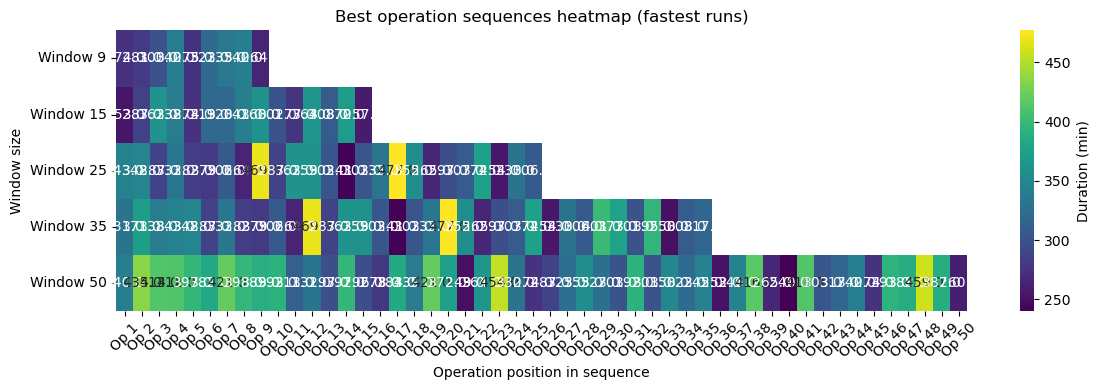

In [19]:
plot_best_run_heatmap(ops, window_sizes=(9, 15, 25, 35, 50))

In [20]:
def global_heatmap(ops, window=10, max_windows=200):
    
    ops = ops.sort_values("start").reset_index(drop=True)
    durations = ops["duration_min"].to_numpy()

    n = len(durations)

    if n < window:
        raise ValueError("Pas assez de données")

    # limite pour lisibilité
    n_windows = min(n - window + 1, max_windows)

    matrix = np.zeros((n_windows, window))

    for i in range(n_windows):
        matrix[i] = durations[i:i+window]

    plt.figure(figsize=(14, 6))

    sns.heatmap(
        matrix,
        cmap="viridis",
        cbar_kws={"label": "Duration (min)"}
    )

    plt.title(f"Global sliding window heatmap (window={window})")
    plt.xlabel("Operation index in window")
    plt.ylabel("Window position in time")

    plt.tight_layout()
    plt.show()

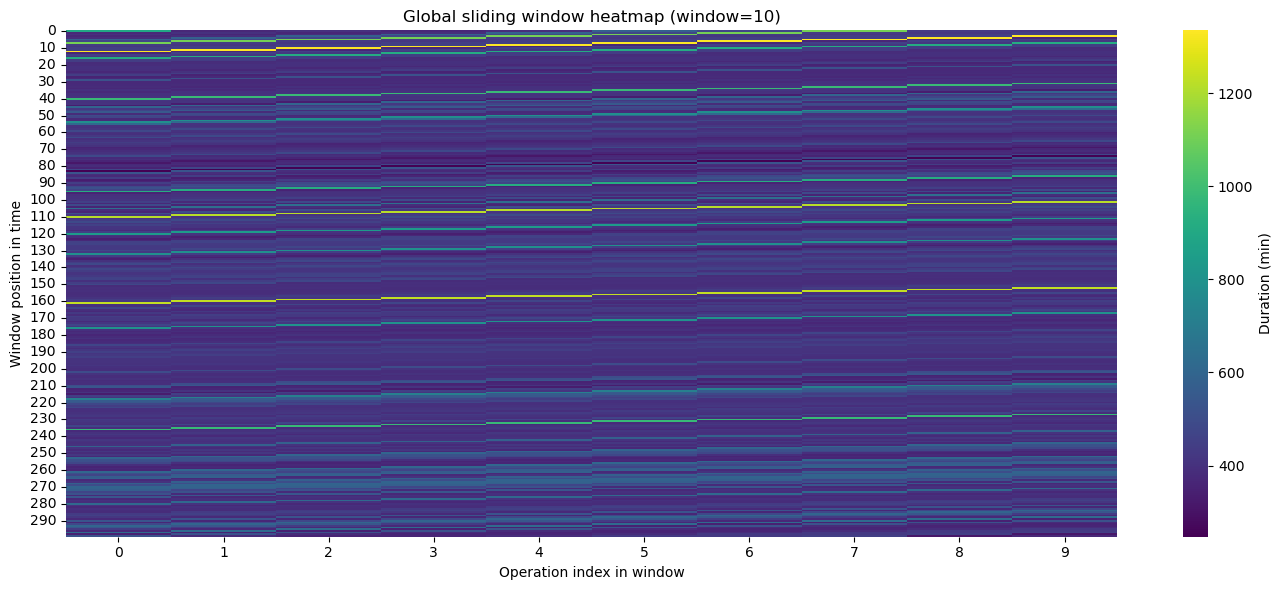

In [21]:
global_heatmap(ops, window=10, max_windows=300)

In [22]:
def sequence_monthly_score(ops, window=10):
    
    ops = ops.sort_values("start").reset_index(drop=True)

    durations = ops["duration_min"].to_numpy()
    starts = ops["start"].to_numpy()

    rows = []

    for i in range(len(ops) - window + 1):

        window_dur = durations[i:i+window]
        window_start = starts[i]

        total = window_dur.sum()
        mean = window_dur.mean()

        score = 1 / mean if mean > 0 else np.nan

        rows.append({
            "start_time": window_start,
            "month": pd.Timestamp(window_start).to_period("M"),
            "total_duration": total,
            "mean_duration": mean,
            "score": score
        })

    df_score = pd.DataFrame(rows)

    return df_score

In [23]:
df_score = sequence_monthly_score(ops, window=10)
df_score.head(100)

/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_38868/1437531416.py:22: UserWarning: Converting to Period representation will drop timezone information.
  "month": pd.Timestamp(window_start).to_period("M"),


,start_time,month,total_duration,mean_duration,score
0,2016-01-01 01:56:00+00:00,2016-01,5427.0,542.7,0.001843
1,2016-01-01 16:52:00+00:00,2016-01,4976.0,497.6,0.002010
2,2016-01-01 22:58:00+00:00,2016-01,5058.0,505.8,0.001977
3,2016-01-02 05:34:00+00:00,2016-01,5997.0,599.7,0.001668
4,2016-01-02 11:38:00+00:00,2016-01,5995.0,599.5,0.001668
...,...,...,...,...,...
95,2016-01-31 03:35:00+00:00,2016-01,4553.0,455.3,0.002196
96,2016-01-31 18:58:00+00:00,2016-01,4270.0,427.0,0.002342
97,2016-02-01 00:48:00+00:00,2016-02,4303.0,430.3,0.002324
98,2016-02-01 07:20:00+00:00,2016-02,4270.0,427.0,0.002342


In [24]:
monthly_perf = (
    df_score.groupby("month")
    .agg(
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        best_score=("score", "max"),
        worst_score=("score", "min"),
        n_sequences=("score", "count")
    )
    .reset_index()
)

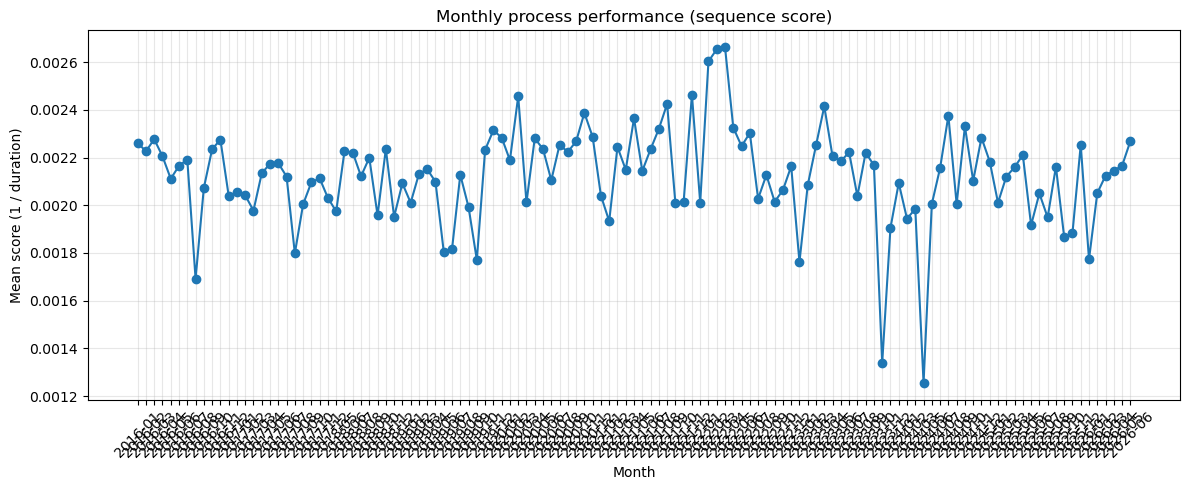

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(monthly_perf["month"].astype(str), monthly_perf["mean_score"], marker="o")

plt.xticks(rotation=45)
plt.title("Monthly process performance (sequence score)")
plt.ylabel("Mean score (1 / duration)")
plt.xlabel("Month")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
def get_reference(ops, x=35):
    
    ops = ops.sort_values("start").reset_index(drop=True)
    durations = ops["duration_min"].to_numpy()

    w = x

    rolling_sum = np.convolve(durations, np.ones(w), mode="valid")
    best_idx = np.argmin(rolling_sum)

    ref_duration = rolling_sum[best_idx]  # durée totale meilleure séquence

    return ref_duration

In [27]:
def build_sliding_windows(ops, window=35):
    
    ops = ops.sort_values("start").reset_index(drop=True)

    rows = []

    for i in range(len(ops) - window + 1):

        window_ops = ops.iloc[i:i+window]

        rows.append({
            "start_time": window_ops["start"].iloc[0],
            "end_time": window_ops["end"].iloc[-1],
            "duration": window_ops["duration_min"].sum()
        })

    return pd.DataFrame(rows)

In [28]:
def add_score(df_windows, ref_duration):

    df = df_windows.copy()

    df["score"] = ref_duration / df["duration"]

    df["month"] = pd.to_datetime(df["start_time"]).dt.to_period("M")

    return df

In [29]:
def monthly_score(df_scored):

    return (
        df_scored
        .groupby("month")
        .agg(
            mean_score=("score", "mean"),
            median_score=("score", "median"),
            best_score=("score", "max"),
            worst_score=("score", "min"),
            n_sequences=("score", "count")
        )
        .reset_index()
    )

In [30]:
win = 35
ref = get_reference(ops, win)
print( 24*60/(ref/win) * 2.71)

windows = build_sliding_windows(ops, window=win)

scored = add_score(windows, ref)

monthly = monthly_score(scored)

monthly

11.925609010739544


/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_38868/2083993682.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = pd.to_datetime(df["start_time"]).dt.to_period("M")


,month,mean_score,median_score,best_score,worst_score,n_sequences
0,2016-01,0.739250,0.730328,0.817663,0.675295,97
1,2016-02,0.741716,0.738617,0.801413,0.691941,83
2,2016-03,0.732320,0.732664,0.802312,0.691941,87
3,2016-04,0.719748,0.722359,0.767524,0.667191,92
4,2016-05,0.683363,0.688116,0.745978,0.627837,94
...,...,...,...,...,...,...
116,2026-02,0.685538,0.694711,0.734590,0.555836,67
117,2026-03,0.688853,0.683843,0.739810,0.638299,75
118,2026-04,0.697418,0.710066,0.761148,0.631124,88
119,2026-05,0.701202,0.693659,0.778904,0.648785,94


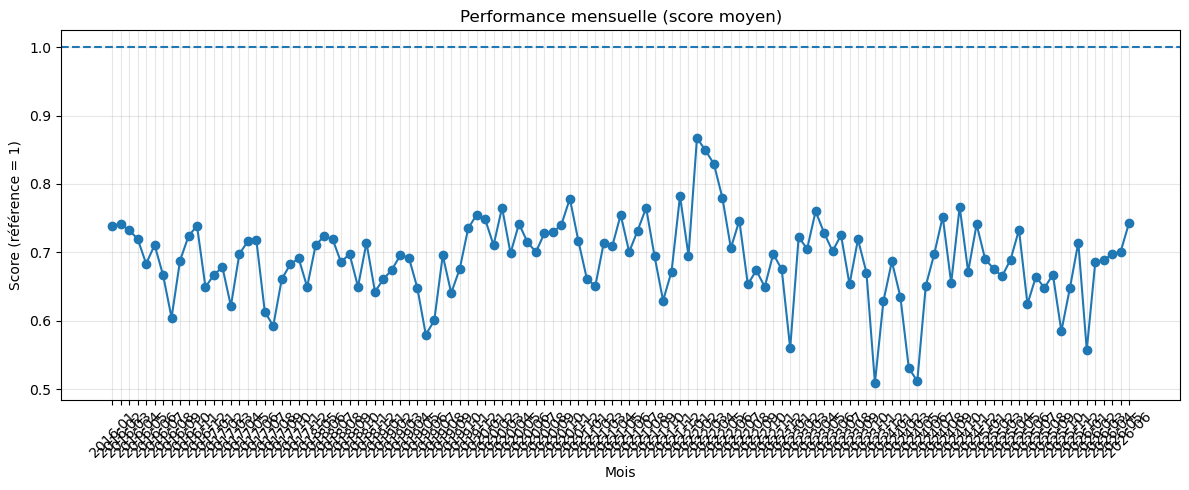

In [31]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["month"].astype(str),
    monthly["mean_score"],
    marker="o"
)

plt.title("Performance mensuelle (score moyen)")
plt.xlabel("Mois")
plt.ylabel("Score (référence = 1)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.axhline(1, linestyle="--")  # baseline référence

plt.tight_layout()
plt.show()

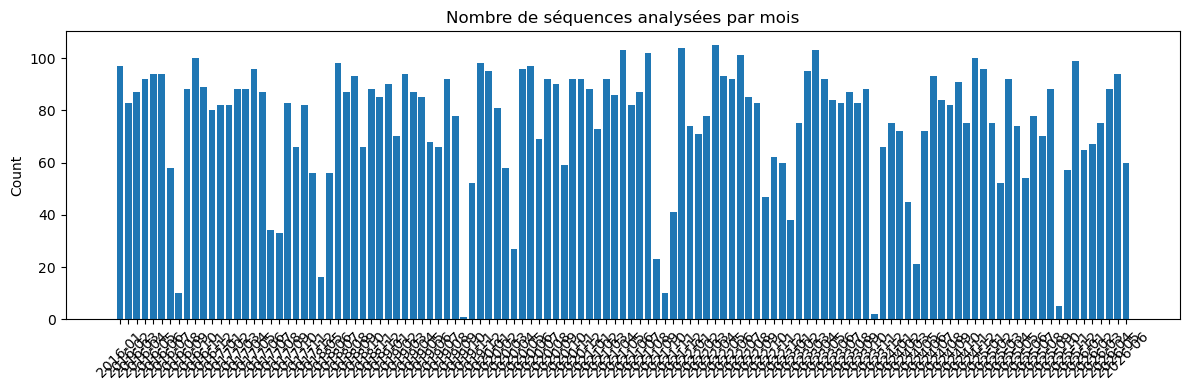

In [32]:
plt.figure(figsize=(12,4))

plt.bar(
    monthly["month"].astype(str),
    monthly["n_sequences"]
)

plt.xticks(rotation=45)
plt.title("Nombre de séquences analysées par mois")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# z-score

In [33]:
def build_windows(ops, window=15):

    ops = ops.sort_values("start").reset_index(drop=True)

    rows = []

    for i in range(len(ops)-window+1):

        w = ops.iloc[i:i+window]

        rows.append({
            "start_time": w["start"].iloc[0],
            "end_time": w["end"].iloc[-1],
            "duration": w["duration_min"].sum()
        })

    return pd.DataFrame(rows)

In [34]:
win = 35
windows = build_windows(ops, window=35)

mu = windows["duration"].mean()
sigma = windows["duration"].std()

windows["z_score"] = -(windows["duration"] - mu) / sigma

In [35]:
windows["month"] = windows["start_time"].dt.to_period("M")

monthly = (
    windows
    .groupby("month")
    .agg(
        mean_z=("z_score","mean"),
        median_z=("z_score","median"),
        std_z=("z_score","std"),
        best_z=("z_score","max"),
        worst_z=("z_score","min"),
        n_runs=("z_score","count")
    )
    .reset_index()
)

/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_38868/1531446397.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  windows["month"] = windows["start_time"].dt.to_period("M")


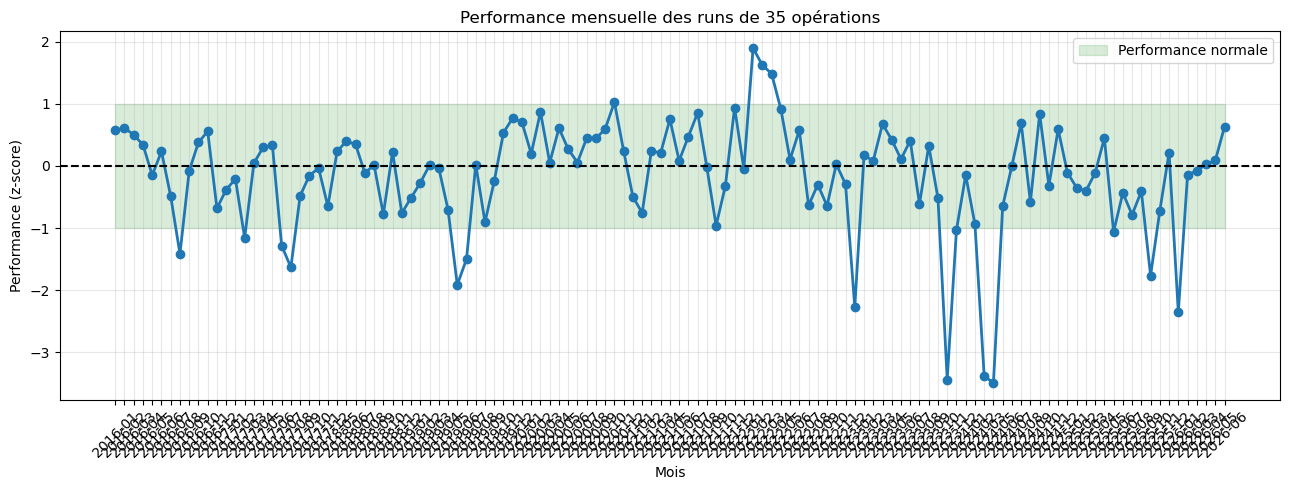

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13,5))

plt.plot(
    monthly["month"].astype(str),
    monthly["mean_z"],
    marker="o",
    linewidth=2
)

plt.axhline(0, color="black", linestyle="--")

plt.fill_between(
    monthly["month"].astype(str),
    -1,
    1,
    alpha=0.15,
    color="green",
    label="Performance normale"
)

plt.xticks(rotation=45)

plt.ylabel("Performance (z-score)")
plt.xlabel("Mois")
plt.title(f"Performance mensuelle des runs de {win} opérations")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
def plot_sequence(ops, result):

    seq = ops.iloc[result["start_index"]:result["end_index"]+1]

    fig, ax = plt.subplots(figsize=(12,4))

    ax.plot(
        seq["value"].values,
        marker="o",
        lw=2
    )

    for i, v in enumerate(seq["value"]):
        ax.text(i, v, str(v), fontsize=8)

    ax.set_xlabel("Position dans le run")
    ax.set_ylabel("value_nop")
    ax.set_title("Enchaînement des opérations")

    plt.tight_layout()
    plt.show()

In [38]:
results

{15: {'start_time': Timestamp('2022-05-26 14:58:00+0000', tz='UTC'),
  'end_time': Timestamp('2022-05-29 21:49:00+0000', tz='UTC'),
  'values_sequence': [587,
   588,
   589,
   590,
   591,
   592,
   593,
   594,
   595,
   596,
   597,
   598,
   599,
   600,
   601],
  'total_duration_min': 4731.0,
  'mean_duration_min': 315.4,
  'median_duration_min': 319.0,
  'std_duration_min': 38.527565889027215,
  'min_duration_min': 253.0,
  'max_duration_min': 370.0,
  'cv': 0.1221546160083298},
 35: {'start_time': Timestamp('2022-03-28 06:55:00+0000', tz='UTC'),
  'end_time': Timestamp('2022-04-09 18:05:00+0000', tz='UTC'),
  'values_sequence': [398,
   399,
   400,
   401,
   402,
   403,
   405,
   406,
   407,
   408,
   409,
   410,
   412,
   413,
   414,
   415,
   416,
   417,
   418,
   419,
   420,
   421,
   423,
   424,
   425,
   426,
   427,
   428,
   429,
   430,
   431,
   432,
   433,
   434,
   435],
  'total_duration_min': 11453.0,
  'mean_duration_min': 327.2285714285714

In [39]:
def plot_best_run(ops, result):

    fig, ax = plt.subplots(figsize=(16,5))

    ax.plot(
        ops["start"],
        ops["duration_min"],
        lw=1,
        color="steelblue"
    )

    # zone du meilleur run
    ax.axvspan(
        result["start_time"],
        result["end_time"],
        color="red",
        alpha=0.3,
        label="Best run"
    )

    # points du meilleur run
    mask = (
        (ops["start"] >= result["start_time"]) &
        (ops["end"] <= result["end_time"])
    )

    ax.scatter(
        ops.loc[mask, "start"],
        ops.loc[mask, "duration_min"],
        color="red",
        s=40
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("Durée (min)")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

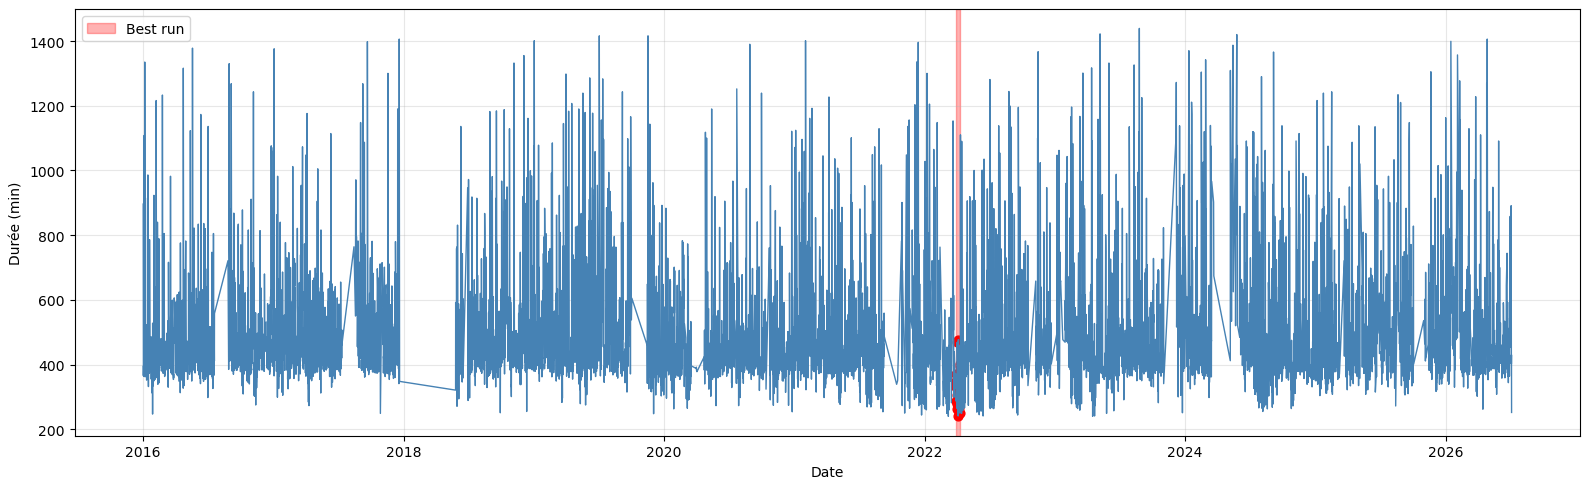

In [40]:
plot_best_run(ops, results[35])

In [41]:
def plot_best_sequence(ops, results, window=15):

    r = results[window]

    seq = ops[
        (ops["start"] >= r["start_time"]) &
        (ops["end"] <= r["end_time"])
    ].copy()

    fig, ax = plt.subplots(figsize=(15,5))

    ax.plot(
        seq["value"],
        seq["duration_min"],
        "-o",
        lw=2,
        ms=6
    )

    ax.set_xlabel("Numéro d'opération")
    ax.set_ylabel("Durée (min)")
    ax.set_title(f"Meilleur run ({window} opérations)")

    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

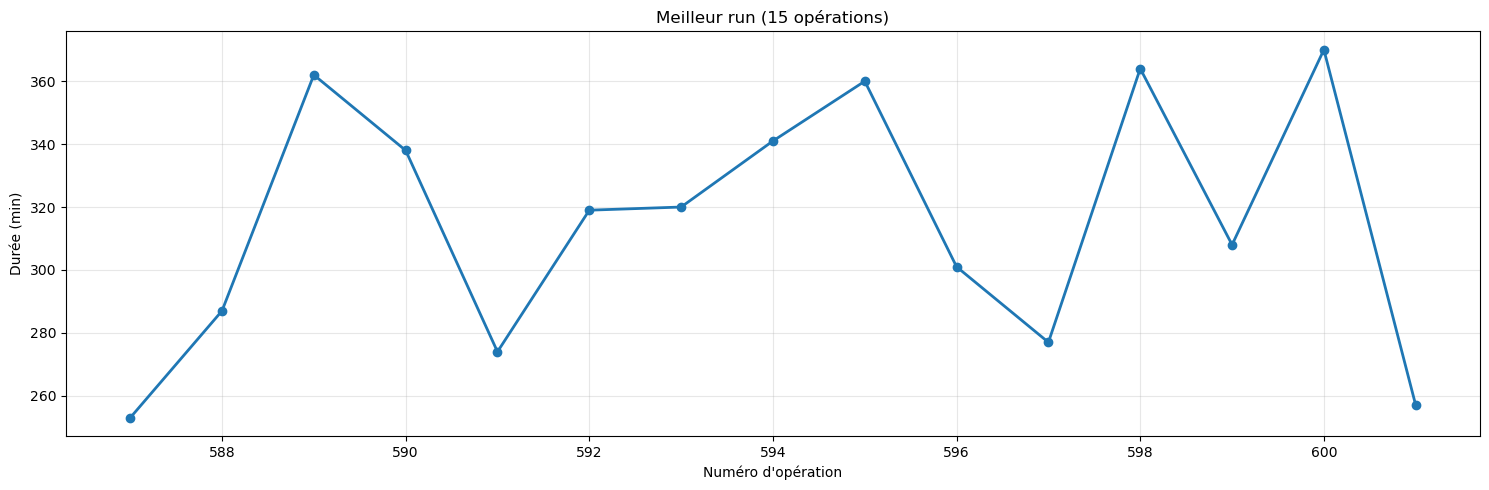

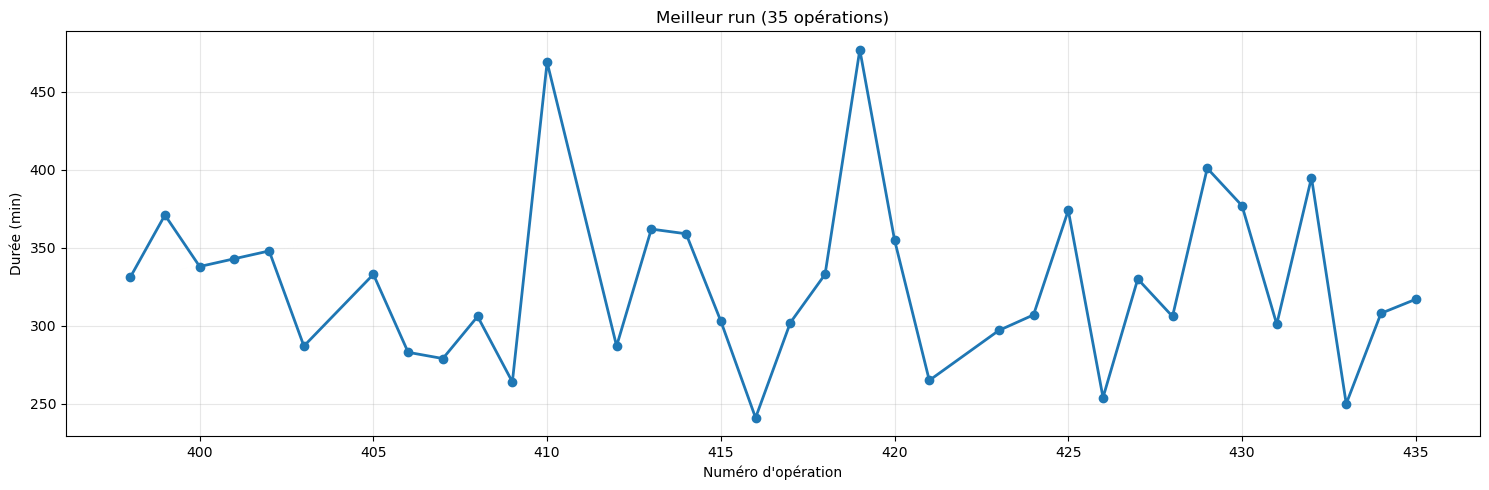

In [42]:
plot_best_sequence(ops, results, 15)
plot_best_sequence(ops, results, 35)

In [43]:
def plot_best_sequence_stats(ops, results, window=15):

    r = results[window]

    seq = ops[
        (ops["start"] >= r["start_time"]) &
        (ops["end"] <= r["end_time"])
    ].copy()

    mean = seq["duration_min"].mean()
    std = seq["duration_min"].std()

    fig, ax = plt.subplots(figsize=(15,5))

    ax.plot(
        seq["value"],
        seq["duration_min"],
        "-o",
        lw=2,
        label="Durée"
    )

    ax.axhline(mean, color="green", label="Moyenne")

    ax.fill_between(
        seq["value"],
        mean-std,
        mean+std,
        alpha=0.2,
        label="±1σ"
    )

    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

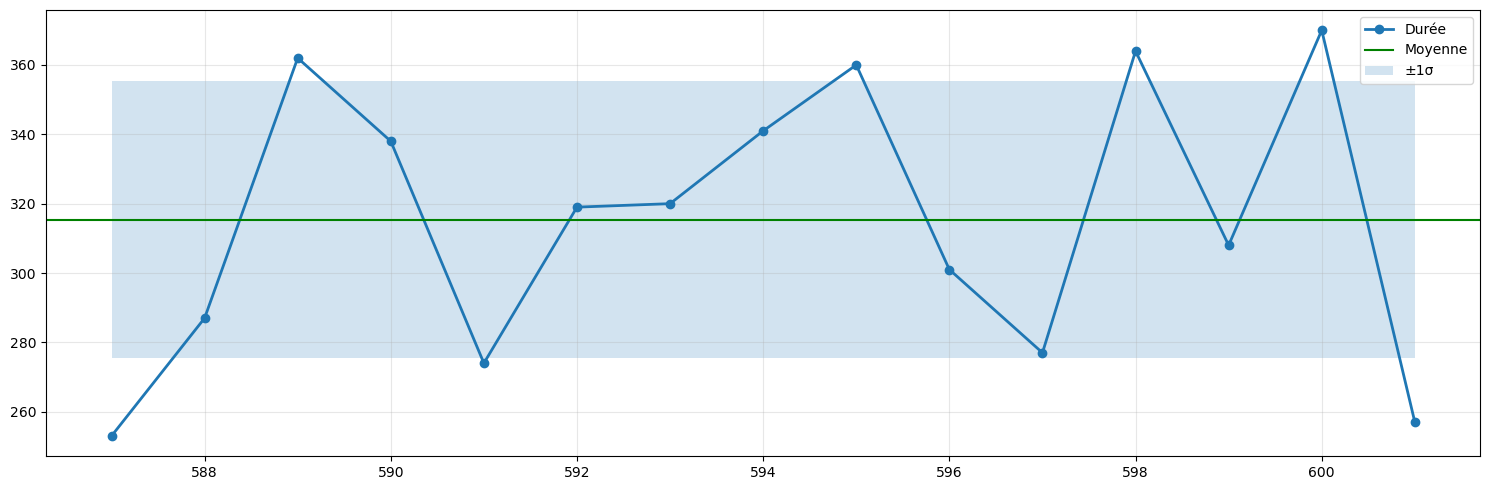

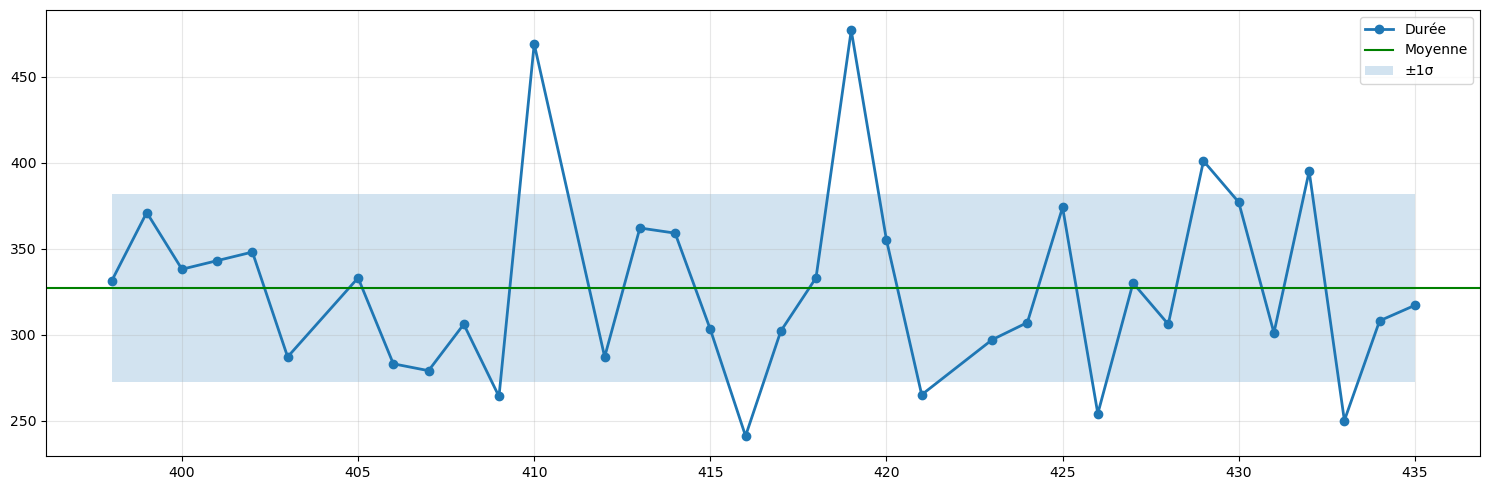

In [44]:
plot_best_sequence_stats(ops, results, 15)  
plot_best_sequence_stats(ops, results, 35)  